# Simulation-Based Inference for a Gaussian Toy Problem

This notebook introduces the basic idea of **Simulation-Based Inference (SBI)** using a simple Gaussian toy model.

**What is SBI?**

In many scientific fields (e.g. cosmology, neuroscience, epidemiology), the forward model that generates data is known and can be simulated, but the likelihood function $P(d \mid \theta)$ is intractable or too expensive to evaluate directly. SBI provides methods to learn the posterior $P(\theta \mid d)$ using only simulated data.

**Why a Gaussian toy problem?**

For a Gaussian prior and a Gaussian likelihood, the true posterior is also Gaussian and can be computed analytically. This makes the Gaussian problem an excellent pedagogical example: we can verify that our SBI method recovers the exact answer.

**Outline**

1. Define the probabilistic model: prior, likelihood, and analytical posterior.
2. Simulate a joint dataset $\{(\theta_i, d_i)\}_{i=1}^N$ from the model.
3. Propose a flexible variational posterior $q_\phi(\theta \mid d)$.
4. Minimize the negative log-likelihood to fit $q_\phi$ to the simulations.
5. Compare the learned posterior with the analytical truth.

In [9]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

**Define the True Probabilistic Model**

We consider a one-dimensional parameter $\theta$ and a one-dimensional observable $d$.

**Prior:**

$$\theta \sim \mathcal{N}(\mu_\theta, \sigma_\theta^2)$$

**Likelihood:**

$$d \mid \theta \sim \mathcal{N}(\theta, \sigma_d^2)$$

Because both the prior and the likelihood are Gaussian, the exact posterior is also Gaussian (by conjugacy):

$$P(\theta \mid d) = \mathcal{N}\left(\theta \;\bigg|\; \frac{\mu_\theta \sigma_d^2 + d \sigma_\theta^2}{\sigma_d^2 + \sigma_\theta^2},\; \frac{\sigma_d^2 \sigma_\theta^2}{\sigma_d^2 + \sigma_\theta^2}\right).$$

We will use this analytical expression as our ground truth.

In [ ]:
# --- Define True Parameters ---

mu_theta    = 0.0   # Mean of the Gaussian prior P(theta)
sigma_theta = 5.0   # Standard deviation of the prior
sigma_d = 0.5   # Standard deviation of the likelihood noise P(d|theta)

print(f"Prior:        theta ~ N(mu_theta={mu_theta}, sigma_theta^2={sigma_theta**2})")
print(f"Likelihood:   d|theta ~ N(theta, sigma_d^2={sigma_d**2})")

Prior:        theta ~ N(mu_theta=0.0, sigma_theta^2=25.0)
Likelihood:   d|theta ~ N(theta, sigma_d^2=0.25)


**Simulate the Joint Distribution $P(\theta, d)$**

In realistic SBI applications, running the simulator is the expensive step. Here, the simulator is trivial: we draw $\theta$ from the prior and then draw $d$ from the likelihood. The resulting pairs $\{(\theta_i, d_i)\}$ approximate the joint distribution $P(\theta, d)$.

Larger $N$ gives a more accurate approximation of the joint distribution and therefore a better-trained posterior.

In [ ]:
# --- Simulate the Joint Distribution P(theta, d) ---

seed = 42
N = 100#_000  # Number of simulations

rng = np.random.default_rng(seed)
# Draw parameters from the prior
theta_samples = rng.normal(mu_theta, sigma_theta, N)

# Draw observables from the likelihood conditioned on each theta
d_samples = rng.normal(theta_samples, sigma_d, N)

print(f"Generated {N:,} joint samples of (theta, d).")

Generated 100 joint samples of (theta, d).


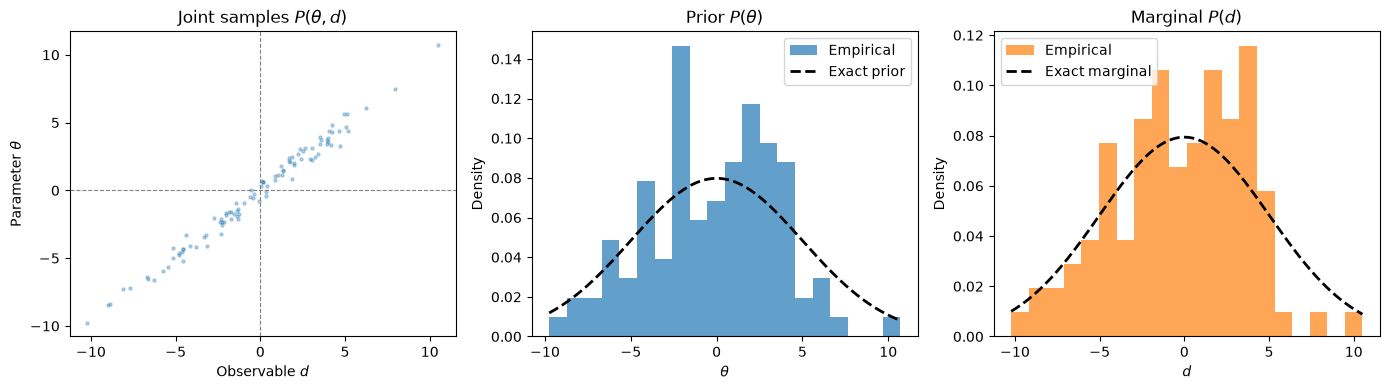

In [ ]:
# Visualize the joint distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Scatter plot of joint samples
axes[0].scatter(d_samples, theta_samples, alpha=0.3, s=5)
axes[0].set_xlabel("Observable $d$")
axes[0].set_ylabel("Parameter $\\theta$")
axes[0].set_title("Joint samples $P(\\theta, d)$")
axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)

# Marginal of theta (prior)
axes[1].hist(theta_samples, bins=20, density=True, color="C0", alpha=0.7, label="Empirical")
theta_grid = np.linspace(theta_samples.min(), theta_samples.max(), 500)
axes[1].plot(theta_grid, sp.stats.norm.pdf(theta_grid, mu_theta, sigma_theta), "k--", lw=2, label="Exact prior")
axes[1].set_xlabel("$\\theta$")
axes[1].set_ylabel("Density")
axes[1].set_title("Prior $P(\\theta)$")
axes[1].legend()

# Marginal of d
axes[2].hist(d_samples, bins=20, density=True, color="C1", alpha=0.7, label="Empirical")
x_grid = np.linspace(d_samples.min(), d_samples.max(), 500)
axes[2].plot(x_grid, sp.stats.norm.pdf(x_grid, mu_theta, np.sqrt(sigma_theta**2 + sigma_d**2)), "k--", lw=2, label="Exact marginal")
axes[2].set_xlabel("$d$")
axes[2].set_ylabel("Density")
axes[2].set_title("Marginal $P(d)$")

axes[2].legend()

plt.tight_layout()
plt.show()

**Propose a Flexible Variational Posterior $q_\phi(\theta \mid d)$**

We do not assume that we know the exact form of the posterior. Instead, we propose a family of distributions $q_\phi(\theta \mid d)$ and try to find the member of that family that best matches the true posterior.

Here we use a **generalized normal distribution** for the posterior, whose mean is a linear function of the observation $d$:

$$q_\phi(\theta \mid d) = \frac{1}{s \, 2 \sqrt{2} \, \Gamma(1 + 1/n)} \exp\left[-\left(\frac{|\theta - (wd+b)|}{\sqrt{2}\,s}\right)^n\right].$$

For $n=2$ this reduces to an ordinary Gaussian. By allowing $n$ to vary, we let the optimizer discover whether the true posterior is Gaussian ($n \to 2$) or has a different shape.

Up to an additive constant, the negative log-likelihood of our simulations under $q_\phi$ is

$$\mathcal{L}(w, b, s, n) = \log s + \log \Gamma\left(1 + \frac{1}{n}\right) + \frac{1}{N} \sum_{i=1}^N \left(\frac{|\theta_i - (w d_i + b)|}{\sqrt{2}\,s}\right)^n.$$

Minimizing this loss finds the posterior approximation that best explains the simulated pairs.

In [ ]:
# --- Define the Proposed Model & Loss Function ---

def loss_function(params):
    """
    Negative log-likelihood of the simulations under the proposed posterior
    q(theta | d) = GeneralizedNormal(mean=w*d+b, scale=s, shape=n).
    """
    w, b, s, n = params

    # Enforce positivity of scale and shape by taking absolute values
    s = np.abs(s)
    n = np.abs(n)

    # Predicted mean of theta for every simulated d
    predicted_mean = w * d_samples + b

    # Negative log-likelihood of a generalized normal distribution
    nll = (
        np.log(s)
        + np.log(sp.special.gamma(1 + 1 / n))
        + np.mean((np.abs(theta_samples - predicted_mean) / (np.sqrt(2) * s)) ** n)
    )

    print(f"Current params: w={w:.8e}, b={b:.8e}, s={s:.8e}, n={n:.8e} | NLL={nll:.8e}")
    return nll

**Optimize the Loss Function**

We use the **L-BFGS-B** algorithm, a quasi-Newton method that is efficient for smooth optimization problems with many parameters. We provide:

- An initial guess for $(w, b, s, n)$.
- Lower bounds $s > 0$ and $n > 0$ to keep the scale and shape parameters positive.

The optimizer iteratively adjusts the parameters to minimize the negative log-likelihood.

In [ ]:
# --- Optimize to minimize the loss ---

initial_guess = [0.0, 0.0, 0.01, 0.01]   # Arbitrary starting parameters
w_init, b_init, s_init, n_init = initial_guess

# Bounds: w and b are unconstrained; s and n must stay positive
bnds = [(None, None), (None, None), (1e-8, None), (1e-8, None)]

result = sp.optimize.minimize(
    loss_function,
    initial_guess,
    method="L-BFGS-B",
    bounds=bnds,
)

# Extract optimized parameters
w_opt, b_opt, s_opt, n_opt = result.x
s_opt = np.abs(s_opt)
n_opt = np.abs(n_opt)

print("\nOptimization finished.")
print(f"Optimized parameters: w={w_opt:.4f}, b={b_opt:.4f}, s={s_opt:.4f}, n={n_opt:.4f}")

Current params: w=0.00000000e+00, b=0.00000000e+00, s=1.00000000e-02, n=1.00000000e-02 | NLL=3.60186674e+02
Current params: w=1.00000000e-08, b=0.00000000e+00, s=1.00000000e-02, n=1.00000000e-02 | NLL=3.60186674e+02
Current params: w=0.00000000e+00, b=1.00000000e-08, s=1.00000000e-02, n=1.00000000e-02 | NLL=3.60186674e+02
Current params: w=0.00000000e+00, b=0.00000000e+00, s=1.00000100e-02, n=1.00000000e-02 | NLL=3.60186674e+02
Current params: w=0.00000000e+00, b=0.00000000e+00, s=1.00000000e-02, n=1.00000100e-02 | NLL=3.60186213e+02
Current params: w=1.87315200e-07, b=1.14682775e-08, s=9.99978306e-03, n=1.01000000e+00 | NLL=2.34506774e+02
Current params: w=1.97315200e-07, b=1.14682775e-08, s=9.99978306e-03, n=1.01000000e+00 | NLL=2.34506772e+02
Current params: w=1.87315200e-07, b=2.14682775e-08, s=9.99978306e-03, n=1.01000000e+00 | NLL=2.34506774e+02
Current params: w=1.87315200e-07, b=1.14682775e-08, s=9.99979306e-03, n=1.01000000e+00 | NLL=2.34506534e+02
Current params: w=1.87315200

**Compare with the Analytical True Posterior**

For our Gaussian prior and Gaussian likelihood, the true posterior has the form

$$P(\theta \mid x) = \mathcal{N}\left(\theta \;\big|\; w_{\text{true}}\,d + b_{\text{true}},\; s_{\text{true}}^2\right),$$

with

$$w_{\text{true}} = \frac{\sigma_\theta^2}{\sigma_d^2 + \sigma_\theta^2}, \qquad
b_{\text{true}} = \frac{\sigma_d^2\,\mu_0}{\sigma_d^2 + \sigma_\theta^2}, \qquad
s_{\text{true}}^2 = \frac{\sigma_d^2\,\sigma_\theta^2}{\sigma_d^2 + \sigma_\theta^2}, \qquad
n_{\text{true}} = 2.$$

Because the true posterior is Gaussian, the optimized shape parameter $n$ should converge to $2$.

In [ ]:
# --- Compare with Analytical True Posterior ---

true_w = (sigma_theta**2) / (sigma_theta**2 + sigma_d**2)
true_b = (sigma_d**2 * mu_theta) / (sigma_theta**2 + sigma_d**2)
true_s = np.sqrt((sigma_theta**2 * sigma_d**2) / (sigma_theta**2 + sigma_d**2))
true_n = 2.0  # Gaussian corresponds to shape parameter n = 2

# Pretty comparison table
print("--- Parameter Recovery via Optimization ---")
print(f"{'Parameter':<15} {'Optimized':>12} {'True':>12} {'Difference':>12}")
print("-" * 55)
print(f"{'Slope (w)':<15} {w_opt:>12.4f} {true_w:>12.4f} {w_opt - true_w:>12.4f}")
print(f"{'Intercept (b)':<15} {b_opt:>12.4f} {true_b:>12.4f} {b_opt - true_b:>12.4f}")
print(f"{'Std Dev (s)':<15} {s_opt:>12.4f} {true_s:>12.4f} {s_opt - true_s:>12.4f}")
print(f"{'Shape (n)':<15} {n_opt:>12.4f} {true_n:>12.4f} {n_opt - true_n:>12.4f}")

--- Parameter Recovery via Optimization ---
Parameter          Optimized         True   Difference
-------------------------------------------------------
Slope (w)             0.9731       0.9901      -0.0170
Intercept (b)        -0.0116       0.0000      -0.0116
Std Dev (s)           0.5076       0.4975       0.0101
Shape (n)             2.3014       2.0000       0.3014


**Visualize the Learned Posterior**

Finally, we compare the learned posterior $q(\theta \mid d)$ with:

Seeing all three curves together shows how optimization reshapes an initial, poorly chosen distribution into the correct posterior. Because the initial shape parameter $n = 0.01$ is extremely small, the initial density can be numerically negligible over the plotting range; conceptually it is a very broad, heavily tailed distribution.

1. the true Gaussian posterior, and
2. the initial guess $q_0(\theta \mid d)$ produced by the starting parameters $(w, b, s, n) = (0, 0, 0.01, 0.01)$.

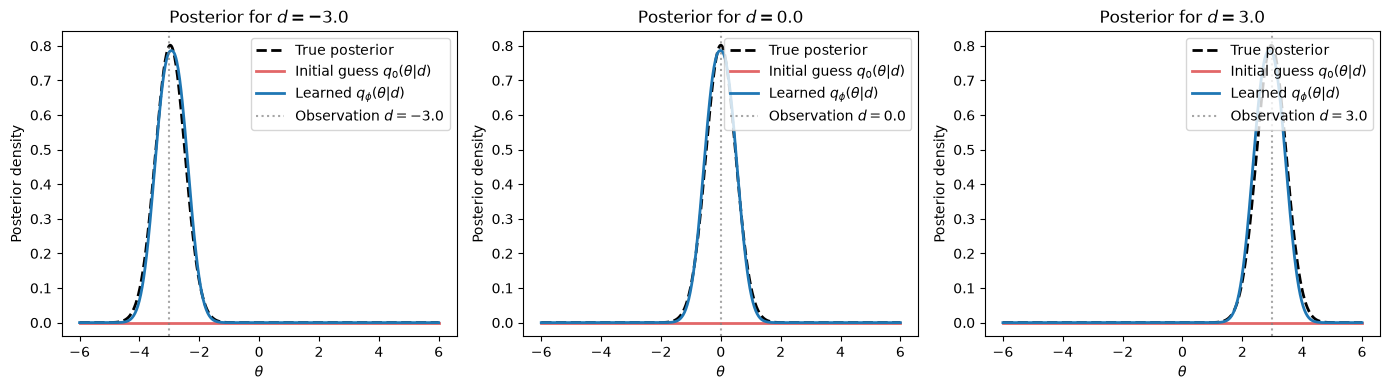

In [ ]:
# --- Visualize learned posterior vs true posterior ---

# Values of d for which we want to inspect the posterior
d_values = [-3.0, 0.0, 3.0]

# Grid over theta for plotting densities
theta_grid = np.linspace(-6, 6, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, d0 in zip(axes, d_values):
    # True Gaussian posterior parameters at this d
    true_mean = true_w * d0 + true_b
    true_std = true_s

    # Learned generalized-normal posterior parameters at this d
    learned_mean = w_opt * d0 + b_opt
    learned_scale = s_opt
    learned_shape = n_opt

    # True posterior density
    true_density = sp.stats.norm.pdf(theta_grid, true_mean, true_std)

    # Learned posterior density (generalized normal)
    # scipy.stats.gennorm uses beta=shape, loc=mean, scale=scale, with
    # pdf(theta) proportional to exp(-(|theta-mean|/scale)^shape).
    # Our parameterization uses scale = sqrt(2) * s, so we rescale.
    learned_density = sp.stats.gennorm.pdf(
        theta_grid,
        beta=learned_shape,
        loc=learned_mean,
        scale=np.sqrt(2) * learned_scale
    )

    # Initial generalized-normal posterior parameters at this d
    initial_mean = w_init * d0 + b_init
    initial_scale = np.abs(s_init)
    initial_shape = np.abs(n_init)

    initial_density = sp.stats.gennorm.pdf(
        theta_grid,
        beta=initial_shape,
        loc=initial_mean,
        scale=np.sqrt(2) * initial_scale
    )

    ax.plot(theta_grid, true_density, "k--", lw=2, label="True posterior")
    ax.plot(theta_grid, initial_density, "C3", lw=2, alpha=0.7, label="Initial guess $q_0(\\theta|d)$")
    ax.plot(theta_grid, learned_density, "C0", lw=2, label="Learned $q_\\phi(\\theta|d)$")
    ax.axvline(d0, color="gray", linestyle=":", alpha=0.7, label=f"Observation $d={d0}$")
    ax.set_xlabel("$\\theta$")
    ax.set_ylabel("Posterior density")
    ax.set_title(f"Posterior for $d = {d0}$")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Key Takeaways**

- **Simulation-Based Inference** replaces an intractable likelihood with a simulator that can be run many times.
- Even a simple variational family $q_\phi(\theta \mid d)$ with a linear mean can recover the exact posterior for a Gaussian problem.
- The optimized parameters should match the analytical posterior parameters: $w$, $b$, $s$, and $n \approx 2$.
- This toy model illustrates the core workflow of SBI: simulate, propose a posterior family, define a loss, optimize, and validate against known analytical results.

**Next steps:**

- Try changing $\mu_\theta$, $\sigma_\theta$, or $\sigma_d$ and re-run the notebook. Do the optimized parameters still match the analytical formulas?
- Explore how the number of simulations $N$ affects the accuracy of parameter recovery.